In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
#!/usr/bin/env python3
from pathlib import Path
import pandas as pd

BASE = Path.home() / "scratch/pang/pang_experiment"
PANG_DIR = BASE / "pangenomes"
OUT = BASE / "pangenome_graph_sizes_mb.tsv"

def first_existing(candidates):
    for p in candidates:
        if p.exists() and p.is_file() and p.stat().st_size > 0:
            return p
    return None

rows = []

for setdir in sorted(PANG_DIR.glob("set_*")):
    if not setdir.is_dir():
        continue

    setname = setdir.name
    outdir = setdir / "output"
    if not outdir.exists():
        continue

    # Prefer d2.gbz (the one you typically map with), else fall back to .gbz
    gbz = first_existing([
        outdir / f"{setname}.d2.gbz",
        outdir / f"{setname}.gbz",
    ])
    if gbz is None:
        continue

    size_bytes = gbz.stat().st_size
    size_mb = size_bytes / (1024 * 1024)

    rows.append({
        "set": setname,
        "gbz_path": str(gbz),
        "gbz_size_mb": round(size_mb, 3),
    })

df = pd.DataFrame(rows)
if not df.empty:
    df = df.sort_values("gbz_size_mb", ascending=False)



In [10]:
df

,set,gbz_path,gbz_size_mb
16,set_all_rep1,/home/tbellagio/scratch/pang/pang_experiment/p...,656.837
15,set_50_rep3,/home/tbellagio/scratch/pang/pang_experiment/p...,570.709
14,set_50_rep2,/home/tbellagio/scratch/pang/pang_experiment/p...,564.277
13,set_50_rep1,/home/tbellagio/scratch/pang/pang_experiment/p...,557.695
12,set_18_rep1,/home/tbellagio/scratch/pang/pang_experiment/p...,339.908
10,set_15_rep2,/home/tbellagio/scratch/pang/pang_experiment/p...,311.308
11,set_15_rep3,/home/tbellagio/scratch/pang/pang_experiment/p...,296.600
9,set_15_rep1,/home/tbellagio/scratch/pang/pang_experiment/p...,292.462
6,set_10_rep1,/home/tbellagio/scratch/pang/pang_experiment/p...,244.155
7,set_10_rep2,/home/tbellagio/scratch/pang/pang_experiment/p...,242.372


In [13]:
#!/usr/bin/env python3
from pathlib import Path
import re
import pandas as pd

BASE = Path.home() / "scratch/pang/pang_experiment"
PANG_DIR = BASE / "pangenomes"
LOG_DIR = BASE / "scripts/built_pang"
OUT = BASE / "pangenome_graph_sizes_mb.tsv"

RUNTIME_RE = re.compile(r"cactus-pangenome has finished after ([0-9.]+) seconds")

# Things that indicate the run failed (add more if you see other patterns)
FAIL_MARKERS = [
    "InsufficientSystemResources",
    "toil.batchSystems.abstractBatchSystem.InsufficientSystemResources",
    "raise InsufficientSystemResources",
    "Traceback (most recent call last)",
    "ERROR",
    "Exception:",
    "Killed",
]

def first_existing(candidates):
    for p in candidates:
        if p.exists() and p.is_file() and p.stat().st_size > 0:
            return p
    return None

def read_tail_text(path: Path, max_lines: int = 4000) -> str:
    """Read the last ~max_lines lines of a file (good enough for logs)."""
    try:
        with path.open("r", errors="ignore") as f:
            lines = f.readlines()
        return "".join(lines[-max_lines:])
    except FileNotFoundError:
        return ""

def is_failed_err(err_path: Path) -> bool:
    tail = read_tail_text(err_path, max_lines=4000)
    # If any failure marker appears anywhere in the tail, treat as failed
    return any(m in tail for m in FAIL_MARKERS)

def parse_runtime_seconds(err_path: Path):
    """Return float seconds if found, else None."""
    if err_path is None:
        return None
    tail = read_tail_text(err_path, max_lines=4000)
    # search backwards-ish by scanning lines reversed
    lines = tail.splitlines()
    for line in reversed(lines):
        m = RUNTIME_RE.search(line)
        if m:
            try:
                return float(m.group(1))
            except ValueError:
                return None
    return None

def best_success_err_for_set(setname: str):
    """
    Choose the best stderr log for runtime:
      - must not look failed
      - must contain the finished runtime line
      - if multiple qualify, pick most recently modified
    Returns (err_path, runtime_seconds) or (None, None)
    """
    err_candidates = sorted(LOG_DIR.glob(f"{setname}.*.err"))
    good = []
    for p in err_candidates:
        if p.stat().st_size == 0:
            continue
        if is_failed_err(p):
            continue
        rt = parse_runtime_seconds(p)
        if rt is None:
            continue
        good.append((p, rt))

    if not good:
        return None, None

    good.sort(key=lambda x: x[0].stat().st_mtime, reverse=True)
    return good[0]  # (path, runtime)

rows = []

for setdir in sorted(PANG_DIR.glob("set_*")):
    if not setdir.is_dir():
        continue

    setname = setdir.name
    outdir = setdir / "output"
    if not outdir.exists():
        continue

    gbz = first_existing([
        outdir / f"{setname}.d2.gbz",
        outdir / f"{setname}.gbz",
    ])
    if gbz is None:
        continue

    size_mb = gbz.stat().st_size / (1024 * 1024)

    err_path, runtime_s = best_success_err_for_set(setname)

    rows.append({
        "set": setname,
        "gbz_size_mb": round(size_mb, 3),
        "runtime_seconds": runtime_s,
        "runtime_hours": (runtime_s / 3600.0) if runtime_s is not None else None,
        "err_log": str(err_path) if err_path else None,
    })

df = pd.DataFrame(rows)

if not df.empty:
    df = df.sort_values("gbz_size_mb", ascending=False)

df.to_csv(OUT, sep="\t", index=False)
print(f"Wrote: {OUT}")


Wrote: /home/tbellagio/scratch/pang/pang_experiment/pangenome_graph_sizes_mb.tsv


In [14]:
df

,set,gbz_size_mb,runtime_seconds,runtime_hours,err_log
16,set_all_rep1,656.837,153244.757687,42.567988,/home/tbellagio/scratch/pang/pang_experiment/s...
15,set_50_rep3,570.709,78531.927998,21.814424,/home/tbellagio/scratch/pang/pang_experiment/s...
14,set_50_rep2,564.277,86737.852187,24.093848,/home/tbellagio/scratch/pang/pang_experiment/s...
13,set_50_rep1,557.695,96149.443838,26.708179,/home/tbellagio/scratch/pang/pang_experiment/s...
12,set_18_rep1,339.908,24718.053740,6.866126,/home/tbellagio/scratch/pang/pang_experiment/s...
10,set_15_rep2,311.308,15176.790705,4.215775,/home/tbellagio/scratch/pang/pang_experiment/s...
11,set_15_rep3,296.600,17646.155756,4.901710,/home/tbellagio/scratch/pang/pang_experiment/s...
9,set_15_rep1,292.462,16245.019771,4.512505,/home/tbellagio/scratch/pang/pang_experiment/s...
6,set_10_rep1,244.155,9060.257915,2.516738,/home/tbellagio/scratch/pang/pang_experiment/s...
7,set_10_rep2,242.372,7833.089651,2.175858,/home/tbellagio/scratch/pang/pang_experiment/s...


In [15]:
import pandas as pd

# df has: set, gbz_path, gbz_size_mb
tmp = df["set"].str.extract(r"^set_(?P<set_size>[^_]+)_rep(?P<rep>\d+)$")
df2 = df.join(tmp)

df2["rep"] = df2["rep"].astype(int)
df2["n_genomes"] = pd.to_numeric(df2["set_size"], errors="coerce")
df2.loc[df2["set_size"] == "all", "n_genomes"] = 69
df2["n_genomes"] = df2["n_genomes"].astype(int)

In [18]:
df2['n_genomes']

16    69
15    50
14    50
13    50
12    18
10    15
11    15
9     15
6     10
7     10
8     10
4      5
3      5
5      5
2      2
1      2
0      2
Name: n_genomes, dtype: int64

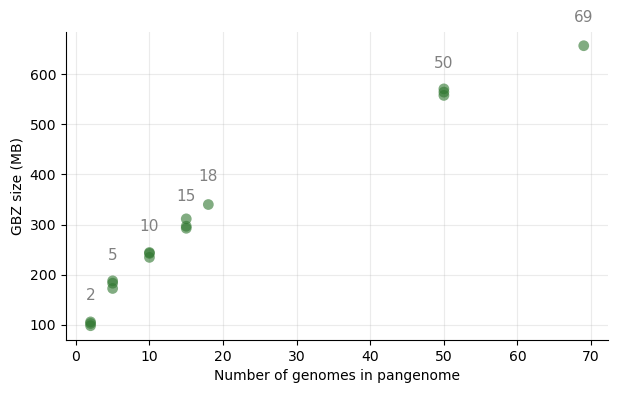

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

df2["n_genomes"] = pd.to_numeric(df2["n_genomes"], errors="coerce")

plt.figure(figsize=(7,4))
ax = plt.gca()

ax.scatter(
    df2["n_genomes"],
    df2["gbz_size_mb"],
    alpha=0.6,
    s=60,
    color="#2E762E",
    edgecolors="none"
)

ax.set_xlabel("Number of genomes in pangenome")
ax.set_ylabel("GBZ size (MB)")

# remove top/right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# grid in background
ax.grid(True, which="major", axis="both", alpha=0.25)
ax.set_axisbelow(True)  # put grid behind points

# --- annotate ONE label per x: show x value (n_genomes) ---
grp = (df2.dropna(subset=["n_genomes", "gbz_size_mb"])
         .groupby("n_genomes", as_index=False)["gbz_size_mb"]
         .mean())

for x, y in zip(grp["n_genomes"], grp["gbz_size_mb"]):
    ax.annotate(
        f"{int(x)}",              # <-- label is number of genomes
        (x, y),
        textcoords="offset points",
        xytext=(0, 15),
        ha="center",
        va="bottom",
        fontsize=11,
        color="grey"
    )

plt.savefig("pangenome_size.png", dpi=300, bbox_inches="tight")
plt.show()


In [28]:
df2.to_csv('pangenome_sizes_n_runtimes.tsv', sep = '\t')

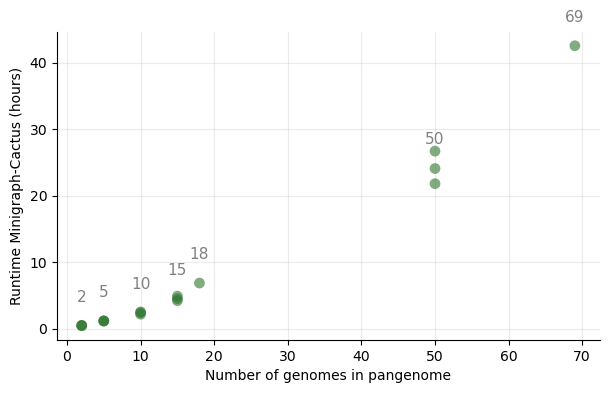

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

df2["n_genomes"] = pd.to_numeric(df2["n_genomes"], errors="coerce")

plt.figure(figsize=(7,4))
ax = plt.gca()

ax.scatter(
    df2["n_genomes"],
    df2["runtime_hours"],
    alpha=0.6,
    s=60,
    color="#2E762E",
    edgecolors="none"
)

ax.set_xlabel("Number of genomes in pangenome")
ax.set_ylabel("Runtime Minigraph-Cactus (hours)")

# remove top/right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# grid in background
ax.grid(True, which="major", axis="both", alpha=0.25)
ax.set_axisbelow(True)  # put grid behind points

# --- annotate ONE label per x: show x value (n_genomes) ---
grp = (df2.dropna(subset=["n_genomes", "runtime_hours"])
         .groupby("n_genomes", as_index=False)["runtime_hours"]
         .mean())

for x, y in zip(grp["n_genomes"], grp["runtime_hours"]):
    ax.annotate(
        f"{int(x)}",              # <-- label is number of genomes
        (x, y),
        textcoords="offset points",
        xytext=(0, 15),
        ha="center",
        va="bottom",
        fontsize=11,
        color="grey"
    )

plt.savefig('pangenome_run_time.png')
plt.show()


In [42]:
def parse_flagstat(flagstat_file):
    metrics = {}
    with open(flagstat_file) as f:
        for line in f:
            if "in total" in line:
                metrics["total_reads"] = int(line.split()[0])
            elif "mapped (" in line:
                metrics["mapped_reads"] = int(line.split()[0])
            elif "properly paired" in line:
                metrics["properly_paired"] = int(line.split()[0])
    return metrics


In [43]:
def parse_samtools_stats(stats_file):
    metrics = {}
    with open(stats_file) as f:
        for line in f:
            if line.startswith("SN\taverage quality:"):
                metrics["mean_mapq"] = float(line.strip().split()[-1])
    return metrics


In [44]:
from pathlib import Path
import re
from datetime import datetime

DT_FMT = "%a %b %d %I:%M:%S %p %Z %Y"
DT_LINE_RE = re.compile(
    r"^(Mon|Tue|Wed|Thu|Fri|Sat|Sun)\s+[A-Z][a-z]{2}\s+\d{1,2}\s+\d{1,2}:\d{2}:\d{2}\s+(AM|PM)\s+\S+\s+\d{4}$"
)

def parse_linear_runtime_from_logs(
    sample: str,
    logs_dir: Path,
    samples_txt: Path,
    prefer_latest_jobid: bool = True,
):
    """
    Parse runtime for a linear mapping sample from Slurm array .out logs.

    Assumes logs look like:
      logs/MAP_LINEAR_<jobid>_<taskid>.out

    And samples_txt contains one sample per line (array index is 1-based).

    Returns dict with:
      runtime_seconds, runtime_minutes, runtime_hours, runtime_start, runtime_end, runtime_log
    Missing values -> None.
    """
    if not samples_txt.exists():
        return {
            "runtime_seconds": None,
            "runtime_minutes": None,
            "runtime_hours": None,
            "runtime_start": None,
            "runtime_end": None,
            "runtime_log": None,
        }

    # taskid = 1-based line number where sample appears in samples.txt
    samples = [l.strip() for l in samples_txt.read_text().splitlines() if l.strip()]
    try:
        taskid = samples.index(sample) + 1
    except ValueError:
        taskid = None

    if taskid is None:
        return {
            "runtime_seconds": None,
            "runtime_minutes": None,
            "runtime_hours": None,
            "runtime_start": None,
            "runtime_end": None,
            "runtime_log": None,
        }

    # Find matching logs for this taskid
    # e.g. MAP_LINEAR_807_1.out
    candidates = list(logs_dir.glob(f"MAP_LINEAR_*_{taskid}.out"))
    if not candidates:
        return {
            "runtime_seconds": None,
            "runtime_minutes": None,
            "runtime_hours": None,
            "runtime_start": None,
            "runtime_end": None,
            "runtime_log": None,
        }

    # If multiple jobids exist, choose latest by mtime (or smallest jobid if you prefer)
    if prefer_latest_jobid:
        outlog = max(candidates, key=lambda p: p.stat().st_mtime)
    else:
        # pick lowest jobid
        def jobid(p):
            m = re.search(r"MAP_LINEAR_(\d+)_\d+\.out$", p.name)
            return int(m.group(1)) if m else 0
        outlog = min(candidates, key=jobid)

    # Parse timestamps: first date line = start, last date line = end
    lines = outlog.read_text(errors="ignore").splitlines()
    dt_lines = [l.strip() for l in lines if DT_LINE_RE.match(l.strip())]

    if len(dt_lines) < 2:
        return {
            "runtime_seconds": None,
            "runtime_minutes": None,
            "runtime_hours": None,
            "runtime_start": None,
            "runtime_end": None,
            "runtime_log": str(outlog),
        }

    start_dt = datetime.strptime(dt_lines[0], DT_FMT)
    end_dt = datetime.strptime(dt_lines[-1], DT_FMT)
    runtime_s = (end_dt - start_dt).total_seconds()

    return {
        "runtime_seconds": runtime_s,
        "runtime_minutes": runtime_s / 60.0,
        "runtime_hours": runtime_s / 3600.0,
        "runtime_start": start_dt.strftime("%Y-%m-%d %H:%M:%S"),
        "runtime_end": end_dt.strftime("%Y-%m-%d %H:%M:%S"),
        "runtime_log": str(outlog),
    }


In [46]:
LINEAR_LOGS = Path.home() / "scratch/pang/pang_experiment/linear_mapping/logs"
LINEAR_SAMPLES_TXT = Path.home() / "scratch/pang/pang_experiment/linear_mapping/samples.txt"

In [48]:
from pathlib import Path
import re
import pandas as pd

LINEAR_BASE = Path.home() / "scratch/pang/pang_experiment/linear_mapping/results"


rows_linear = []

for sample_dir in LINEAR_BASE.iterdir():
    if not sample_dir.is_dir():
        continue

    sample = sample_dir.name

    flagstat = sample_dir / f"{sample}.flagstat.txt"
    stats = sample_dir / f"{sample}.stats.txt"

    if not flagstat.exists():
        continue

    lin_stats = parse_flagstat(flagstat)
    lin_stats.update(
    parse_linear_runtime_from_logs(
        sample=sample,
        logs_dir=LINEAR_LOGS,
        samples_txt=LINEAR_SAMPLES_TXT,
    )
    )
    
    if stats.exists():
        lin_stats.update(parse_samtools_stats(stats))

    lin_stats["pct_mapped"] = (
        lin_stats["mapped_reads"] / lin_stats["total_reads"]
    )

    lin_stats["pct_properly_paired"] = (
        lin_stats["properly_paired"] / lin_stats["total_reads"]
    )

    rows_linear.append({
        "method": "linear",
        "set": "TAIR10",
        "rep": "NA",
        "sample": sample,
        "n_genomes": 1,
        **lin_stats
    })


In [49]:
linear_stats = pd.DataFrame(rows_linear)

In [50]:
total_reads = linear_stats[['sample', 'total_reads']].copy()

In [51]:
linear_stats

,method,set,rep,sample,n_genomes,total_reads,mapped_reads,properly_paired,runtime_seconds,runtime_minutes,runtime_hours,runtime_start,runtime_end,runtime_log,mean_mapq,pct_mapped,pct_properly_paired
0,linear,TAIR10,NA,S3,1,54724732,49787440,46009600,1835.0,30.583333,0.509722,2026-02-03 09:58:36,2026-02-03 10:29:11,/home/tbellagio/scratch/pang/pang_experiment/l...,39.0,0.909780,0.840746
1,linear,TAIR10,NA,S4,1,59200354,53708848,46585684,2033.0,33.883333,0.564722,2026-02-03 09:58:36,2026-02-03 10:32:29,/home/tbellagio/scratch/pang/pang_experiment/l...,39.0,0.907239,0.786916
2,linear,TAIR10,NA,S7,1,65543874,59220728,52925806,2187.0,36.450000,0.607500,2026-02-03 09:58:36,2026-02-03 10:35:03,/home/tbellagio/scratch/pang/pang_experiment/l...,39.0,0.903528,0.807487
3,linear,TAIR10,NA,S5,1,68373910,61846988,55210542,2349.0,39.150000,0.652500,2026-02-03 09:58:36,2026-02-03 10:37:45,/home/tbellagio/scratch/pang/pang_experiment/l...,39.1,0.904541,0.807480
4,linear,TAIR10,NA,S8,1,74670578,67758766,59056720,2510.0,41.833333,0.697222,2026-02-03 09:58:37,2026-02-03 10:40:27,/home/tbellagio/scratch/pang/pang_experiment/l...,39.0,0.907436,0.790897
5,linear,TAIR10,NA,S2,1,50889070,46271677,41800358,1742.0,29.033333,0.483889,2026-02-03 09:58:36,2026-02-03 10:27:38,/home/tbellagio/scratch/pang/pang_experiment/l...,38.9,0.909266,0.821401
6,linear,TAIR10,NA,S6,1,70974545,63976040,56070062,2366.0,39.433333,0.657222,2026-02-03 09:58:36,2026-02-03 10:38:02,/home/tbellagio/scratch/pang/pang_experiment/l...,39.0,0.901394,0.790002
7,linear,TAIR10,NA,S1,1,78895060,70693169,64622230,2711.0,45.183333,0.753056,2026-02-03 09:58:36,2026-02-03 10:43:47,/home/tbellagio/scratch/pang/pang_experiment/l...,39.0,0.896040,0.819091


In [52]:
import re
from pathlib import Path
import pandas as pd

In [53]:
from pathlib import Path
import re
from datetime import datetime

ISO_TS_RE = re.compile(r"\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}(?:[+-]\d{2}:\d{2})?")

def parse_pangenome_mapping_runtime_from_logs(
    set_name: str,
    sample: str,
    logs_dir: Path,
    prefer_latest: bool = True,
):
    """
    Parse runtime for vg giraffe mapping from Slurm .out logs like:
      logs/map_<set_name>_<sample>.<jobid>.out
    Example contents:
      ▶ START 2026-01-27T09:20:21-08:00
      ▶ END   2026-01-27T10:51:31-08:00
      ▶ RUNTIME_SECONDS 5470

    Returns dict with:
      vg_runtime_seconds, vg_runtime_minutes, vg_runtime_hours,
      vg_start, vg_end, vg_log

    Missing values -> None.
    """
    pattern = f"map_{set_name}_{sample}.*.out"
    candidates = list(logs_dir.glob(pattern))
    if not candidates:
        # sometimes logs might live elsewhere; return empty
        return {
            "vg_runtime_seconds": None,
            "vg_runtime_minutes": None,
            "vg_runtime_hours": None,
            "vg_start": None,
            "vg_end": None,
            "vg_log": None,
        }

    outlog = max(candidates, key=lambda p: p.stat().st_mtime) if prefer_latest else candidates[0]

    start_iso = None
    end_iso = None
    runtime_s = None

    for line in outlog.read_text(errors="ignore").splitlines():
        line = line.strip()
        if "RUNTIME_SECONDS" in line:
            # e.g. "▶ RUNTIME_SECONDS 5470"
            parts = line.split()
            # last token should be the number
            try:
                runtime_s = float(parts[-1])
            except Exception:
                pass
        elif line.startswith("▶ START"):
            m = ISO_TS_RE.search(line)
            if m:
                start_iso = m.group(0)
        elif line.startswith("▶ END"):
            m = ISO_TS_RE.search(line)
            if m:
                end_iso = m.group(0)

    # If runtime wasn't printed, compute from timestamps (if present)
    if runtime_s is None and start_iso and end_iso:
        try:
            sdt = datetime.fromisoformat(start_iso)
            edt = datetime.fromisoformat(end_iso)
            runtime_s = (edt - sdt).total_seconds()
        except Exception:
            runtime_s = None

    return {
        "runtime_seconds": runtime_s,
        "runtime_minutes": (runtime_s / 60.0) if runtime_s is not None else None,
        "runtime_hours": (runtime_s / 3600.0) if runtime_s is not None else None,
        "start": start_iso,
        "end": end_iso,
        "log": str(outlog),
    }


In [54]:
SCRIPTS_LOGDIR = Path.home() / "scratch/pang/pang_experiment/scripts/mapping_poolseq"


In [56]:
BASE = Path.home() / "scratch/pang/pang_experiment/pangenomes"

def parse_vg_stats(stats_file):
    metrics = {}
    with open(stats_file) as f:
        for line in f:
            line = line.strip()

            if line.startswith("Total alignments:"):
                metrics["total_reads_nosupp"] = int(line.split(":")[1])

            elif line.startswith("Total aligned:"):
                metrics["mapped_reads"] = int(line.split(":")[1])

            elif line.startswith("Total properly paired:"):
                metrics["properly_paired"] = int(line.split(":")[1])

            elif line.startswith("Mapping quality:"):
                m = re.search(r"mean ([\d\.]+), median (\d+)", line)
                if m:
                    metrics["mean_mapq"] = float(m.group(1))
                    metrics["median_mapq"] = int(m.group(2))

            elif line.startswith("Total time:"):
                # example: "Total time: 63599.7 seconds"
                metrics["mapping_time_sec"] = float(
                    line.replace("Total time:", "")
                        .replace("seconds", "")
                        .strip()
                )

            elif line.startswith("Speed:"):
                # example: "Speed: 1230.19 reads/second"
                metrics["reads_per_sec"] = float(
                    line.split()[1]
                )
            elif line.startswith("Total perfect:"):
                metrics["perfect_reads"] = int(line.split(":")[1])

            elif line.startswith("Total gapless"):
                metrics["gapless_reads"] = int(line.split(":")[1])


    return metrics



rows = []

for set_dir in BASE.glob("set_*_rep*"):
    set_name = set_dir.name              # set_10_rep2
    set_label = "_".join(set_name.split("_")[:2])  # set_10
    rep = set_name.split("_")[2]         # rep2

    # infer number of genomes
    n_lookup = {
        "set_02": 2,
        "set_05": 5,
        "set_10": 10,
        "set_15": 15,
        "set_18": 18,
        "set_50": 50,
        "set_all": 69
    }
    n_genomes = n_lookup.get(set_label)

    mapping_dir = set_dir / "mapping" / "seedmix"
    if not mapping_dir.exists():
        continue

    for sample_dir in mapping_dir.iterdir():
        if not sample_dir.is_dir():
            continue

        stats_file = sample_dir / f"{sample_dir.name}.stats.txt"
        if not stats_file.exists():
            continue

        stats = parse_vg_stats(stats_file)

        stats.update(
            parse_pangenome_mapping_runtime_from_logs(
                set_name=set_name,                 # IMPORTANT: full name like set_10_rep3
                sample=sample_dir.name,            # S7
                logs_dir=SCRIPTS_LOGDIR,
            )
        )


        #if "total_reads" not in stats:
        #    continue

        #stats["pct_mapped"] = stats["mapped_reads"] / stats["total_reads"]
        #stats["pct_perfect"] = stats["perfect_reads"] / stats["total_reads"]
        #stats["pct_gapless"] = stats["gapless_reads"] / stats["total_reads"]
    

        rows.append({
            "set": set_label,
            "rep": rep,
            "sample": sample_dir.name,
            "n_genomes": n_genomes,
            **stats
        })


In [57]:
df_map = pd.DataFrame(rows)

In [58]:
df_map

,set,rep,sample,n_genomes,total_reads_nosupp,mapped_reads,perfect_reads,gapless_reads,properly_paired,mean_mapq,median_mapq,mapping_time_sec,reads_per_sec,runtime_seconds,runtime_minutes,runtime_hours,start,end,log
0,set_02,rep3,S6,2,70309590,60077673,27534737,54137840,60019102,45.1759,60,57175.8,1229.71,2056.0,34.266667,0.571111,2026-01-30T23:13:12-08:00,2026-01-30T23:47:28-08:00,/home/tbellagio/scratch/pang/pang_experiment/s...
1,set_02,rep3,S1,2,78239732,67463146,31404296,60828839,67633884,45.5800,60,48148.0,1624.99,1747.0,29.116667,0.485278,2026-01-30T22:43:11-08:00,2026-01-30T23:12:18-08:00,/home/tbellagio/scratch/pang/pang_experiment/s...
2,set_02,rep3,S5,2,67755386,58363292,26861387,52558480,58392852,45.2750,60,53448.1,1267.69,1942.0,32.366667,0.539444,2026-01-30T23:05:59-08:00,2026-01-30T23:38:21-08:00,/home/tbellagio/scratch/pang/pang_experiment/s...
3,set_02,rep3,S8,2,73950880,63498756,29282055,57260529,63353874,45.1679,60,60751.9,1217.26,2180.0,36.333333,0.605556,2026-01-30T23:15:17-08:00,2026-01-30T23:51:37-08:00,/home/tbellagio/scratch/pang/pang_experiment/s...
4,set_02,rep3,S2,2,50474180,44004645,20317331,39713969,44059472,45.2155,60,40071.6,1259.60,1459.0,24.316667,0.405278,2026-01-30T22:46:26-08:00,2026-01-30T23:10:45-08:00,/home/tbellagio/scratch/pang/pang_experiment/s...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,set_02,rep1,S5,2,67755386,58366746,26870034,52572321,58380640,45.2737,60,55067.7,1230.40,1994.0,33.233333,0.553889,2026-01-30T21:22:46-08:00,2026-01-30T21:56:00-08:00,/home/tbellagio/scratch/pang/pang_experiment/s...
127,set_02,rep1,S2,2,50474180,44006623,20323322,39723283,44054116,45.2132,60,34121.9,1479.23,1224.0,20.400000,0.340000,2026-01-30T20:58:16-08:00,2026-01-30T21:18:40-08:00,/home/tbellagio/scratch/pang/pang_experiment/s...
128,set_02,rep1,S8,2,73950880,63503434,29291410,57275602,63337634,45.1688,60,63258.6,1169.03,2261.0,37.683333,0.628056,2026-01-30T21:59:17-08:00,2026-01-30T22:36:58-08:00,/home/tbellagio/scratch/pang/pang_experiment/s...
129,set_02,rep1,S6,2,70309590,60081467,27543679,54152077,60002740,45.1734,60,63725.4,1103.32,2279.0,37.983333,0.633056,2026-01-30T21:39:57-08:00,2026-01-30T22:17:56-08:00,/home/tbellagio/scratch/pang/pang_experiment/s...


In [59]:
df_map.sort_values(["n_genomes", "rep", "sample"], inplace=True)
df_map.reset_index(drop=True, inplace=True)

In [60]:
df_map = df_map.merge(total_reads, on ='sample')

In [61]:
df_map["pct_properly_paired"]  = df_map['properly_paired'] / df_map['total_reads']
df_map["pct_mapped"] = df_map["mapped_reads"] / df_map["total_reads"]
df_map["pct_perfect"] = df_map["perfect_reads"] / df_map["total_reads"]
df_map["pct_gapless"] = df_map["gapless_reads"] / df_map["total_reads"]

In [62]:
df_map

,set,rep,sample,n_genomes,total_reads_nosupp,mapped_reads,perfect_reads,gapless_reads,properly_paired,mean_mapq,...,runtime_minutes,runtime_hours,start,end,log,total_reads,pct_properly_paired,pct_mapped,pct_perfect,pct_gapless
0,set_02,rep1,S1,2,78239732,67465949,31414003,60843182,67624660,45.5792,...,29.433333,0.490556,2026-01-30T20:23:59-08:00,2026-01-30T20:53:25-08:00,/home/tbellagio/scratch/pang/pang_experiment/s...,78895060,0.857147,0.855135,0.398175,0.771191
1,set_02,rep1,S2,2,50474180,44006623,20323322,39723283,44054116,45.2132,...,20.400000,0.340000,2026-01-30T20:58:16-08:00,2026-01-30T21:18:40-08:00,/home/tbellagio/scratch/pang/pang_experiment/s...,50889070,0.865689,0.864756,0.399365,0.780586
2,set_02,rep1,S3,2,54308174,47709124,21981449,42932700,47871174,45.6573,...,31.850000,0.530833,2026-01-30T21:03:58-08:00,2026-01-30T21:35:49-08:00,/home/tbellagio/scratch/pang/pang_experiment/s...,54724732,0.874763,0.871802,0.401673,0.784521
3,set_02,rep1,S4,2,58646998,50248771,23143466,45365088,50077268,44.7898,...,24.583333,0.409722,2026-01-30T21:22:04-08:00,2026-01-30T21:46:39-08:00,/home/tbellagio/scratch/pang/pang_experiment/s...,59200354,0.845895,0.848792,0.390935,0.766298
4,set_02,rep1,S5,2,67755386,58366746,26870034,52572321,58380640,45.2737,...,33.233333,0.553889,2026-01-30T21:22:46-08:00,2026-01-30T21:56:00-08:00,/home/tbellagio/scratch/pang/pang_experiment/s...,68373910,0.853844,0.853641,0.392987,0.768894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,set_50,rep3,S7,50,64976120,59395691,40858636,57829705,58738054,44.5752,...,253.766667,4.229444,2026-02-01T16:29:09-08:00,2026-02-01T20:42:55-08:00,/home/tbellagio/scratch/pang/pang_experiment/s...,65543874,0.896164,0.906197,0.623378,0.882305
127,set_50,rep3,S8,50,73950880,67209288,46236910,65450594,65973974,44.2271,...,222.466667,3.707778,2026-02-01T17:18:04-08:00,2026-02-01T21:00:32-08:00,/home/tbellagio/scratch/pang/pang_experiment/s...,74670578,0.883534,0.900077,0.619212,0.876525
128,set_all,rep1,S1,69,78239732,72477745,51672517,70882445,71823252,44.1166,...,494.050000,8.234167,2026-02-02T09:37:50-08:00,2026-02-02T17:51:53-08:00,/home/tbellagio/scratch/pang/pang_experiment/s...,78895060,0.910364,0.918660,0.654953,0.898440
129,set_all,rep1,S2,69,50474180,47296078,33388780,46260641,46692206,43.7813,...,329.300000,5.488333,2026-02-02T09:37:55-08:00,2026-02-02T15:07:13-08:00,/home/tbellagio/scratch/pang/pang_experiment/s...,50889070,0.917529,0.929396,0.656109,0.909049


In [63]:
linear_stats

,method,set,rep,sample,n_genomes,total_reads,mapped_reads,properly_paired,runtime_seconds,runtime_minutes,runtime_hours,runtime_start,runtime_end,runtime_log,mean_mapq,pct_mapped,pct_properly_paired
0,linear,TAIR10,NA,S3,1,54724732,49787440,46009600,1835.0,30.583333,0.509722,2026-02-03 09:58:36,2026-02-03 10:29:11,/home/tbellagio/scratch/pang/pang_experiment/l...,39.0,0.909780,0.840746
1,linear,TAIR10,NA,S4,1,59200354,53708848,46585684,2033.0,33.883333,0.564722,2026-02-03 09:58:36,2026-02-03 10:32:29,/home/tbellagio/scratch/pang/pang_experiment/l...,39.0,0.907239,0.786916
2,linear,TAIR10,NA,S7,1,65543874,59220728,52925806,2187.0,36.450000,0.607500,2026-02-03 09:58:36,2026-02-03 10:35:03,/home/tbellagio/scratch/pang/pang_experiment/l...,39.0,0.903528,0.807487
3,linear,TAIR10,NA,S5,1,68373910,61846988,55210542,2349.0,39.150000,0.652500,2026-02-03 09:58:36,2026-02-03 10:37:45,/home/tbellagio/scratch/pang/pang_experiment/l...,39.1,0.904541,0.807480
4,linear,TAIR10,NA,S8,1,74670578,67758766,59056720,2510.0,41.833333,0.697222,2026-02-03 09:58:37,2026-02-03 10:40:27,/home/tbellagio/scratch/pang/pang_experiment/l...,39.0,0.907436,0.790897
5,linear,TAIR10,NA,S2,1,50889070,46271677,41800358,1742.0,29.033333,0.483889,2026-02-03 09:58:36,2026-02-03 10:27:38,/home/tbellagio/scratch/pang/pang_experiment/l...,38.9,0.909266,0.821401
6,linear,TAIR10,NA,S6,1,70974545,63976040,56070062,2366.0,39.433333,0.657222,2026-02-03 09:58:36,2026-02-03 10:38:02,/home/tbellagio/scratch/pang/pang_experiment/l...,39.0,0.901394,0.790002
7,linear,TAIR10,NA,S1,1,78895060,70693169,64622230,2711.0,45.183333,0.753056,2026-02-03 09:58:36,2026-02-03 10:43:47,/home/tbellagio/scratch/pang/pang_experiment/l...,39.0,0.896040,0.819091


In [64]:
stats_linear_pang = pd.concat([df_map, linear_stats])

In [65]:
stats_linear_pang['runtime_hours']

0    0.490556
1    0.340000
2    0.530833
3    0.409722
4    0.553889
       ...   
3    0.652500
4    0.697222
5    0.483889
6    0.657222
7    0.753056
Name: runtime_hours, Length: 139, dtype: float64

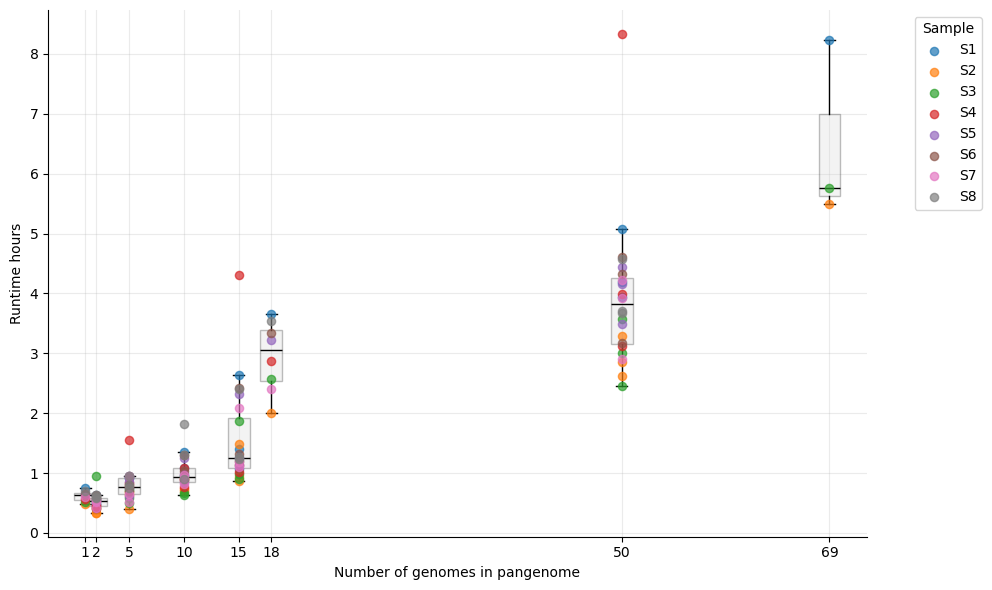

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ensure numeric
stats_linear_pang["n_genomes"] = pd.to_numeric(stats_linear_pang["n_genomes"], errors="coerce")
stats_linear_pang["runtime_hours"] = pd.to_numeric(stats_linear_pang["runtime_hours"], errors="coerce")

d = stats_linear_pang.dropna(subset=["n_genomes", "runtime_hours"]).copy()

fig, ax = plt.subplots(figsize=(10, 6))

# --- boxplots at numeric positions ---
xs = np.sort(d["n_genomes"].unique())
data_by_x = [d.loc[d["n_genomes"] == x, "runtime_hours"].values for x in xs]

ax.boxplot(
    data_by_x,
    positions=xs,
    widths=2,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor="lightgray", edgecolor="black", alpha=0.25),  # transparent
    medianprops=dict(color="black"),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
)

# --- scatter points, colored by sample ---
samples = d["sample"].unique()
for s in samples:
    sub = d[d["sample"] == s]
    ax.scatter(
        sub["n_genomes"],
        sub["runtime_hours"],
        s=35,
        alpha=0.7,
        label=str(s),
        zorder=3
    )

ax.set_xlabel("Number of genomes in pangenome")
ax.set_ylabel("Runtime hours")

# realistic x axis ticks (only show existing x values)
ax.set_xticks(xs)
ax.set_xticklabels([str(int(x)) if float(x).is_integer() else str(x) for x in xs])

# add whitespace on the left (and a bit on right) so first group isn't on the edge
xmin, xmax = xs.min(), xs.max()
pad_left = max(1, 0.05 * (xmax - xmin))          # at least 1 genome worth of padding
pad_right = 0.05 * (xmax - xmin)
ax.set_xlim(xmin - pad_left, xmax + pad_right)

# remove top/right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# grid behind everything
ax.grid(True, which="major", axis="both", alpha=0.25)
ax.set_axisbelow(True)

# legend outside
ax.legend(title="Sample", bbox_to_anchor=(1.05, 1), loc="upper left")

fig.tight_layout()
fig.savefig("runtime_hours_mapped.png", dpi=300, bbox_inches="tight")
plt.show()


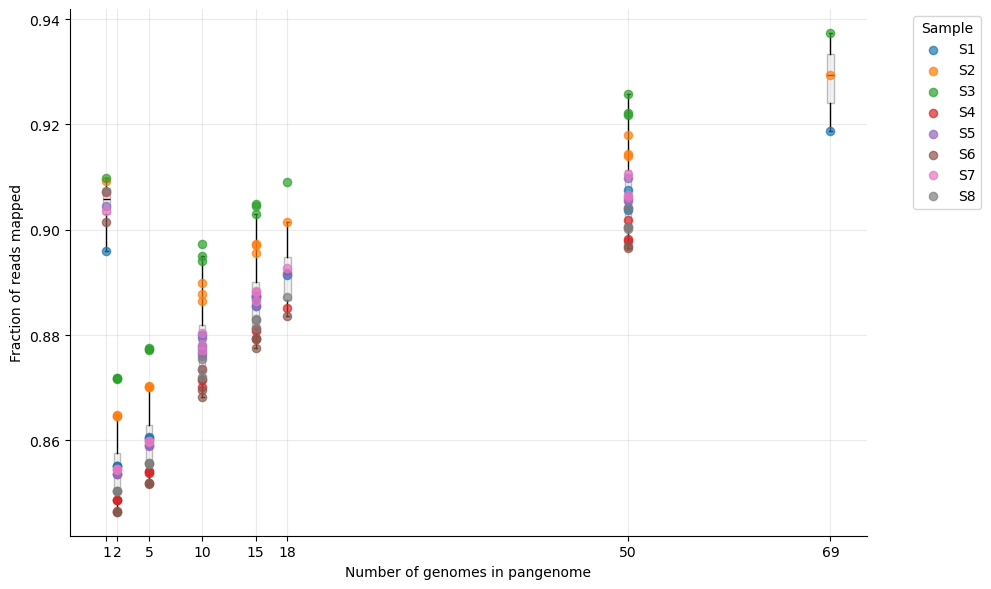

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ensure numeric
stats_linear_pang["n_genomes"] = pd.to_numeric(stats_linear_pang["n_genomes"], errors="coerce")
stats_linear_pang["pct_mapped"] = pd.to_numeric(stats_linear_pang["pct_mapped"], errors="coerce")

d = stats_linear_pang.dropna(subset=["n_genomes", "pct_mapped"]).copy()

fig, ax = plt.subplots(figsize=(10, 6))

# --- boxplots at numeric positions ---
xs = np.sort(d["n_genomes"].unique())
data_by_x = [d.loc[d["n_genomes"] == x, "pct_mapped"].values for x in xs]

ax.boxplot(
    data_by_x,
    positions=xs,
    widths=0.6,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor="lightgray", edgecolor="black", alpha=0.25),
    medianprops=dict(color="black"),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
)

# --- scatter points, colored by sample ---
samples = d["sample"].unique()
for s in samples:
    sub = d[d["sample"] == s]
    ax.scatter(
        sub["n_genomes"],
        sub["pct_mapped"],
        s=35,
        alpha=0.7,
        label=str(s),
        zorder=3
    )

ax.set_xlabel("Number of genomes in pangenome")
ax.set_ylabel("Fraction of reads mapped")

# ticks only at observed x values
ax.set_xticks(xs)
ax.set_xticklabels([str(int(x)) if float(x).is_integer() else str(x) for x in xs])

# whitespace on left (and a bit on right)
xmin, xmax = xs.min(), xs.max()
pad_left = max(1, 0.05 * (xmax - xmin))
pad_right = 0.05 * (xmax - xmin)
ax.set_xlim(xmin - pad_left, xmax + pad_right)

# remove top/right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# grid behind everything
ax.grid(True, which="major", axis="both", alpha=0.25)
ax.set_axisbelow(True)

# legend outside
ax.legend(title="Sample", bbox_to_anchor=(1.05, 1), loc="upper left")

fig.tight_layout()
fig.savefig("fraction_of_reads_mapped.png", dpi=300, bbox_inches="tight")
plt.show()


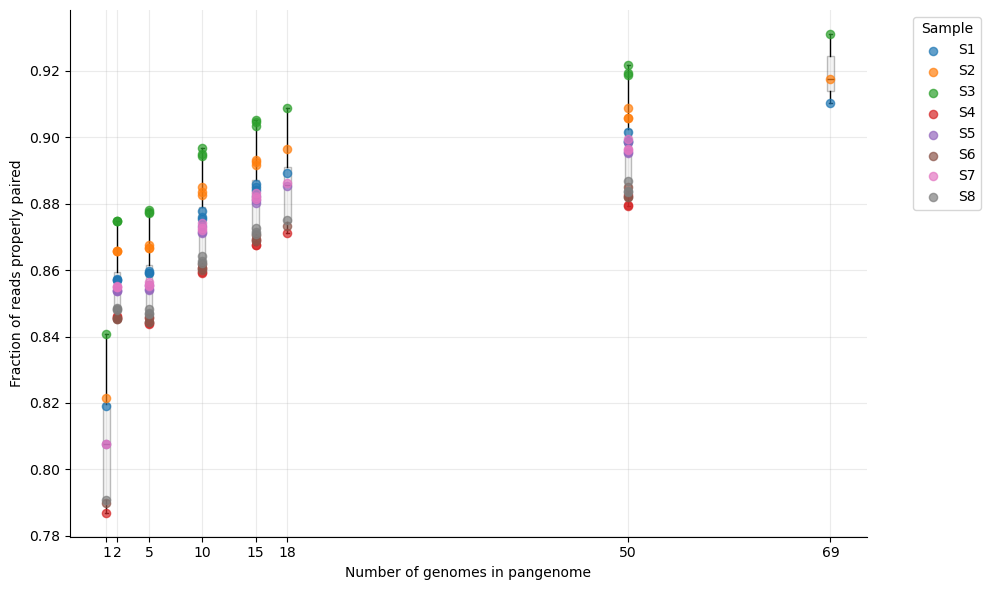

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ensure numeric
stats_linear_pang["n_genomes"] = pd.to_numeric(stats_linear_pang["n_genomes"], errors="coerce")
stats_linear_pang["pct_properly_paired"] = pd.to_numeric(stats_linear_pang["pct_properly_paired"], errors="coerce")

d = stats_linear_pang.dropna(subset=["n_genomes", "pct_properly_paired"]).copy()

fig, ax = plt.subplots(figsize=(10, 6))

# --- boxplots at numeric positions (real spacing) ---
xs = np.sort(d["n_genomes"].unique())
data_by_x = [d.loc[d["n_genomes"] == x, "pct_properly_paired"].values for x in xs]

ax.boxplot(
    data_by_x,
    positions=xs,
    widths=0.6,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor="lightgray", edgecolor="black", alpha=0.25),  # transparent
    medianprops=dict(color="black"),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
)

# --- scatter points, colored by sample ---
samples = d["sample"].unique()
for s in samples:
    sub = d[d["sample"] == s]
    ax.scatter(
        sub["n_genomes"],
        sub["pct_properly_paired"],
        s=35,
        alpha=0.7,
        label=str(s),
        zorder=3
    )

ax.set_xlabel("Number of genomes in pangenome")
ax.set_ylabel("Fraction of reads properly paired")

# ticks only at observed x values
ax.set_xticks(xs)
ax.set_xticklabels([str(int(x)) if float(x).is_integer() else str(x) for x in xs])

# whitespace on left (and a bit on right)
xmin, xmax = xs.min(), xs.max()
pad_left = max(1, 0.05 * (xmax - xmin))
pad_right = 0.05 * (xmax - xmin)
ax.set_xlim(xmin - pad_left, xmax + pad_right)

# remove top/right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# grid behind everything
ax.grid(True, which="major", axis="both", alpha=0.25)
ax.set_axisbelow(True)

# legend outside
ax.legend(title="Sample", bbox_to_anchor=(1.05, 1), loc="upper left")

fig.tight_layout()
fig.savefig("fraction_of_reads_prprl_paired.png", dpi=300, bbox_inches="tight")
plt.show()


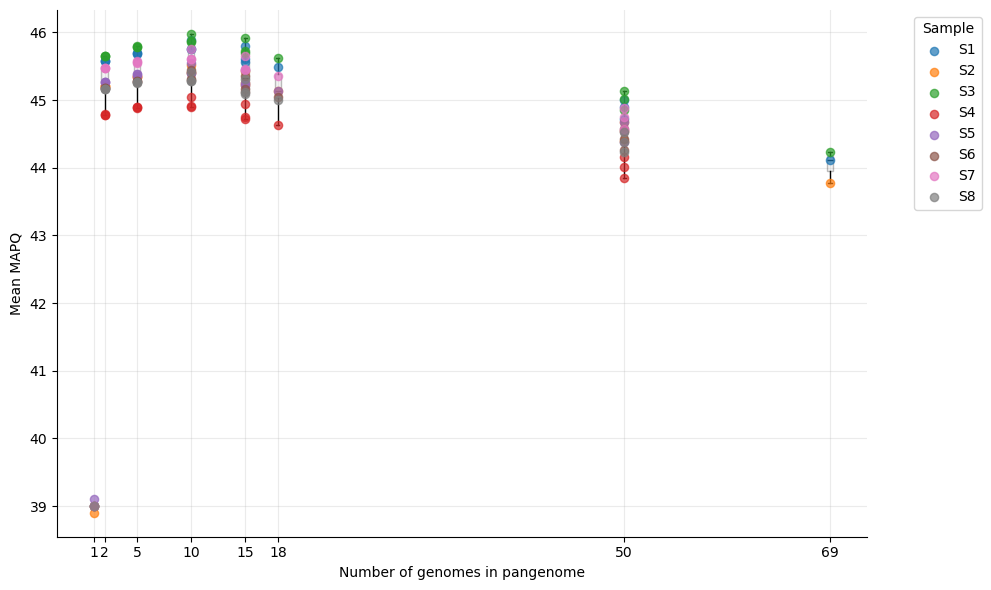

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ensure numeric
stats_linear_pang["n_genomes"] = pd.to_numeric(stats_linear_pang["n_genomes"], errors="coerce")
stats_linear_pang["mean_mapq"] = pd.to_numeric(stats_linear_pang["mean_mapq"], errors="coerce")

d = stats_linear_pang.dropna(subset=["n_genomes", "mean_mapq"]).copy()

fig, ax = plt.subplots(figsize=(10, 6))

# --- boxplots at numeric positions (real spacing) ---
xs = np.sort(d["n_genomes"].unique())
data_by_x = [d.loc[d["n_genomes"] == x, "mean_mapq"].values for x in xs]

ax.boxplot(
    data_by_x,
    positions=xs,
    widths=0.6,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor="lightgray", edgecolor="black", alpha=0.25),  # transparent
    medianprops=dict(color="black"),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
)

# --- scatter points, colored by sample ---
samples = d["sample"].unique()
for s in samples:
    sub = d[d["sample"] == s]
    ax.scatter(
        sub["n_genomes"],
        sub["mean_mapq"],
        s=35,
        alpha=0.7,
        label=str(s),
        zorder=3
    )

ax.set_xlabel("Number of genomes in pangenome")
ax.set_ylabel("Mean MAPQ")

# ticks only at observed x values
ax.set_xticks(xs)
ax.set_xticklabels([str(int(x)) if float(x).is_integer() else str(x) for x in xs])

# whitespace on left (and a bit on right)
xmin, xmax = xs.min(), xs.max()
pad_left = max(1, 0.05 * (xmax - xmin))
pad_right = 0.05 * (xmax - xmin)
ax.set_xlim(xmin - pad_left, xmax + pad_right)

# remove top/right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# grid behind everything
ax.grid(True, which="major", axis="both", alpha=0.25)
ax.set_axisbelow(True)

# legend outside
ax.legend(title="Sample", bbox_to_anchor=(1.05, 1), loc="upper left")

fig.tight_layout()
fig.savefig("mean_mapq.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Boxplot (no hue)
sns.boxplot(
    data=stats_linear_pang,
    x="n_genomes",
    y="pct_mapped",
    color="lightgray",
    fliersize=0
)

# Stripplot with sample-based colors
sns.stripplot(
    data=stats_linear_pang,
    x="n_genomes",
    y="pct_mapped",
    hue="sample",
    dodge=False,      # keep points centered per box
    alpha=0.7,
    size=5
)

plt.ylabel("Fraction of reads mapped")
plt.xlabel("Number of genomes in pangenome")

# Move legend outside (important, otherwise cluttered)
plt.legend(
    title="Sample",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Boxplot (no hue)
sns.boxplot(
    data=stats_linear_pang,
    x="n_genomes",
    y="pct_mapped",
    color="lightgray",
    fliersize=0
)

# Stripplot with sample-based colors
sns.stripplot(
    data=stats_linear_pang,
    x="n_genomes",
    y="pct_mapped",
    hue="sample",
    dodge=False,      # keep points centered per box
    alpha=0.7,
    size=5
)

plt.ylabel("Fraction of reads mapped")
plt.xlabel("Number of genomes in pangenome")

# Move legend outside (important, otherwise cluttered)
plt.legend(
    title="Sample",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [40]:
78818808 - 579076

78239732

In [43]:
75725096 / 78818808

0.9607490638528814

In [42]:
76304172 / 78818808

0.9680959904899856

In [44]:
76304172 - 579076

75725096

In [45]:
78818808 - 2514636

76304172

In [ ]:
75725096 

In [24]:
df_map

,set,rep,sample,n_genomes,total_reads,mapped_reads,perfect_reads,gapless_reads,properly_paired,mean_mapq,median_mapq,mapping_time_sec,reads_per_sec,pct_mapped,pct_perfect,pct_gapless
0,set_02,rep1,S1,2,78239732,74019223,40995783,68445989,73591874,43.3844,60,67914.4,1152.040,0.946057,0.523977,0.874824
1,set_02,rep1,S2,2,50474180,48362310,26607382,44762431,47949728,43.1068,60,45674.2,1105.090,0.958159,0.527148,0.886838
2,set_02,rep1,S3,2,54308174,52448391,28827283,48431671,52234208,43.6210,60,46642.0,1164.360,0.965755,0.530809,0.891793
3,set_02,rep1,S4,2,58646998,55377031,30556174,51287491,54445038,42.5012,60,56449.0,1038.940,0.944243,0.521019,0.874512
4,set_02,rep1,S5,2,67755386,64753981,35913935,59890069,64061150,42.8888,60,61086.5,1109.170,0.955702,0.530053,0.883916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,set_18,rep1,S8,18,73950880,71164066,48633680,68808503,69717460,42.2715,60,307234.0,240.699,0.962315,0.657648,0.930462
79,set_30,rep1,S1,30,78239732,75230821,51774617,72762868,74608666,42.9079,60,312738.0,250.176,0.961542,0.661743,0.929999
80,set_30,rep1,S2,30,50474180,49157113,33514906,47559020,48583850,42.6579,60,209065.0,241.428,0.973906,0.664001,0.942245
81,set_30,rep1,S3,30,54308174,53318268,36539510,51552378,52995414,43.2201,60,219901.0,246.966,0.981772,0.672818,0.949256


In [38]:
67914/60

1131.9

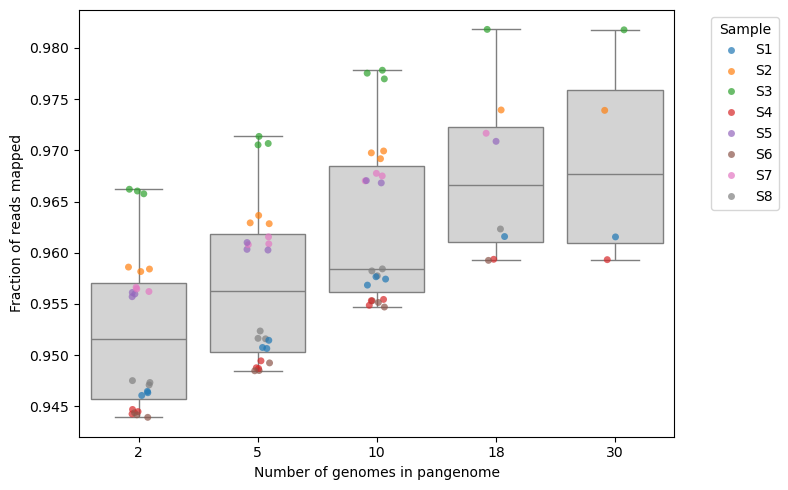

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Boxplot (no hue)
sns.boxplot(
    data=df_map,
    x="n_genomes",
    y="pct_mapped",
    color="lightgray",
    fliersize=0
)

# Stripplot with sample-based colors
sns.stripplot(
    data=df_map,
    x="n_genomes",
    y="pct_mapped",
    hue="sample",
    dodge=False,      # keep points centered per box
    alpha=0.7,
    size=5
)

plt.ylabel("Fraction of reads mapped")
plt.xlabel("Number of genomes in pangenome")

# Move legend outside (important, otherwise cluttered)
plt.legend(
    title="Sample",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [31]:
df_map

,set,rep,sample,n_genomes,total_reads,mapped_reads,perfect_reads,gapless_reads,properly_paired,mean_mapq,median_mapq,mapping_time_sec,reads_per_sec,pct_mapped,pct_perfect,pct_gapless
0,set_02,rep1,S1,2,78239732,74019223,40995783,68445989,73591874,43.3844,60,67914.4,1152.040,0.946057,0.523977,0.874824
1,set_02,rep1,S2,2,50474180,48362310,26607382,44762431,47949728,43.1068,60,45674.2,1105.090,0.958159,0.527148,0.886838
2,set_02,rep1,S3,2,54308174,52448391,28827283,48431671,52234208,43.6210,60,46642.0,1164.360,0.965755,0.530809,0.891793
3,set_02,rep1,S4,2,58646998,55377031,30556174,51287491,54445038,42.5012,60,56449.0,1038.940,0.944243,0.521019,0.874512
4,set_02,rep1,S5,2,67755386,64753981,35913935,59890069,64061150,42.8888,60,61086.5,1109.170,0.955702,0.530053,0.883916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,set_18,rep1,S8,18,73950880,71164066,48633680,68808503,69717460,42.2715,60,307234.0,240.699,0.962315,0.657648,0.930462
79,set_30,rep1,S1,30,78239732,75230821,51774617,72762868,74608666,42.9079,60,312738.0,250.176,0.961542,0.661743,0.929999
80,set_30,rep1,S2,30,50474180,49157113,33514906,47559020,48583850,42.6579,60,209065.0,241.428,0.973906,0.664001,0.942245
81,set_30,rep1,S3,30,54308174,53318268,36539510,51552378,52995414,43.2201,60,219901.0,246.966,0.981772,0.672818,0.949256


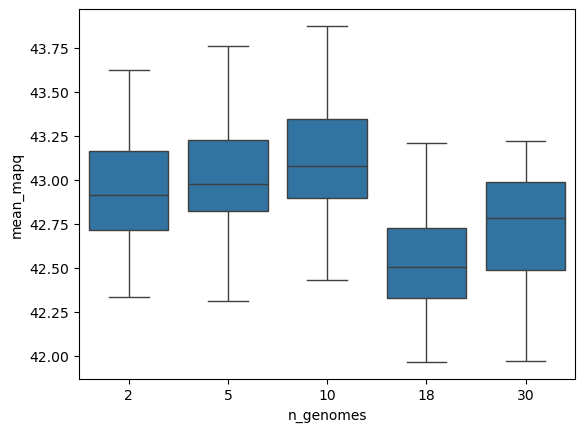

In [32]:
sns.boxplot(
    data=df_map,
    x="n_genomes",
    y="mean_mapq"
)
plt.show()


In [20]:
579076 + 78239732

78818808

In [ ]:
total_reads = 78818808

total_reads = 78239732

mapped_reads_l = 76304172
prop_mapped_reads_l = 71465104
mapped_reads_l/total_reads

prop_mapped_reads_l/total_reads

mapped_reads_p = 68497717
prop_mapped_reads_p = 68763068
mapped_reads_p/total_reads

prop_mapped_reads_p/total_reads

In [41]:
pip install pysam

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 23.1 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [42]:
import pysam

def count_perfect_linear(bam):
    bamf = pysam.AlignmentFile(bam)
    total = 0
    perfect = 0

    for read in bamf:
        if read.is_unmapped or read.is_secondary or read.is_supplementary:
            continue
        total += 1
        if read.get_tag("NM") == 0:
            perfect += 1

    return total, perfect


In [43]:
import pysam
from pathlib import Path

def count_perfect_linear(bam_path):
    bam = pysam.AlignmentFile(bam_path, "rb")

    total = 0
    perfect = 0

    for read in bam:
        # mirror vg "primary alignment" logic
        if read.is_unmapped:
            continue
        if read.is_secondary or read.is_supplementary:
            continue

        total += 1

        # NM tag = edit distance (mismatches + indels)
        try:
            if read.get_tag("NM") == 0:
                perfect += 1
        except KeyError:
            pass

    bam.close()
    return total, perfect


In [44]:
LINEAR_BASE = Path.home() / "scratch/pang/pang_experiment/linear_mapping/results"

rows_linear = []

for sample_dir in LINEAR_BASE.iterdir():
    if not sample_dir.is_dir():
        continue

    sample = sample_dir.name
    bam = sample_dir / f"{sample}.sorted.bam"
    flagstat = sample_dir / f"{sample}.flagstat.txt"

    if not bam.exists():
        continue

    total, perfect = count_perfect_linear(bam)

    rows_linear.append({
        "set": "TAIR10",
        "rep": "NA",
        "sample": sample,
        "n_genomes": 1,
        "total_reads": total,
        "perfect_reads": perfect,
        "pct_perfect": perfect / total,
        "method": "linear"
    })


In [45]:
rows_linear

[{'set': 'TAIR10',
  'rep': 'NA',
  'sample': 'S1',
  'n_genomes': 1,
  'total_reads': 75725096,
  'perfect_reads': 39712274,
  'pct_perfect': 0.5244268557942798,
  'method': 'linear'}]

In [46]:
df_map

,set,rep,sample,n_genomes,total_reads,mapped_reads,perfect_reads,gapless_reads,properly_paired,mean_mapq,median_mapq,mapping_time_sec,reads_per_sec,pct_mapped,pct_perfect,pct_gapless
0,set_02,rep1,S1,2,78239732,66923781,35556040,62066852,67270378,45.3854,60,63599.7,1230.190,0.855368,0.454450,0.793291
1,set_02,rep1,S2,2,50474180,43662311,23030370,40525283,43828552,45.0514,60,42436.4,1189.410,0.865043,0.456280,0.802891
2,set_02,rep1,S3,2,54308174,47391347,24989441,43893263,47670268,45.4686,60,44364.5,1224.140,0.872637,0.460141,0.808226
3,set_02,rep1,S4,2,58646998,49833789,26185683,46264439,49841474,44.6091,60,51376.7,1141.510,0.849724,0.446497,0.788863
4,set_02,rep1,S5,2,67755386,57913670,30386172,53670663,58134216,45.1005,60,57104.2,1186.520,0.854746,0.448469,0.792124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,set_30,rep3,S4,30,58646998,51151032,33052514,49461694,50714142,44.6581,60,90070.5,651.124,0.872185,0.563584,0.843380
124,set_30,rep3,S5,30,67755386,59491955,38403507,57467654,59361836,45.1639,60,82780.6,818.494,0.878040,0.566796,0.848164
125,set_30,rep3,S6,30,70309590,61212354,39416796,59143186,60875056,45.0650,60,106826.0,658.169,0.870612,0.560618,0.841182
126,set_30,rep3,S7,30,64976120,57112694,36998256,55188208,56988412,45.3796,60,96675.9,672.103,0.878980,0.569413,0.849361


In [5]:
samfile = pysam.AlignmentFile("your_bam", "rb")
for read in samfile.fetch():
     cig=read.cigarstring #for cigarstring
     aligned=read.get_aligned_pairs() # will give you the aligned pairs

NameError: name 'pysam' is not defined

In [2]:
import pysam

def bam_identity_stats(
    bam_path,
    min_identity=0.99,
    max_softclip_frac=0.01
):
    bam = pysam.AlignmentFile(bam_path, "rb")

    total_reads = 0
    aligned_reads = 0
    fully_mapped_reads = 0
    high_identity_reads = 0

    for read in bam.fetch(until_eof=True):
        total_reads += 1

        # Skip unmapped, secondary, supplementary alignments
        if read.is_unmapped or read.is_secondary or read.is_supplementary:
            continue

        aligned_reads += 1

        aligned_len = 0        # bases consuming the read
        softclip_len = 0       # soft-clipped read bases

        # Parse CIGAR
        for op, length in read.cigartuples:
            if op in {0, 7, 8, 1}:   # M, =, X, I  (consume read bases)
                aligned_len += length
            elif op == 4:            # S (soft clip)
                softclip_len += length
            # D (2) intentionally excluded — consumes reference only

        if aligned_len == 0:
            continue

        read_len = aligned_len + softclip_len

        # Fully-mapped criterion (allow small soft clipping)
        if softclip_len / read_len > max_softclip_frac:
            continue

        fully_mapped_reads += 1

        # Compute identity
        if not read.has_tag("NM"):
            continue

        nm = read.get_tag("NM")  # mismatches + indels
        identity = 1 - (nm / aligned_len)

        if identity >= min_identity:
            high_identity_reads += 1

    bam.close()

    return {
        "total_reads": total_reads,
        "aligned_reads": aligned_reads,
        "fully_mapped_reads": fully_mapped_reads,
        "high_identity_reads": high_identity_reads,
        "pct_high_identity": high_identity_reads / total_reads
    }


In [7]:
import pysam
import pandas as pd

def bam_identity_df(
    bam_path,
    max_softclip_frac=0.01
):
    bam = pysam.AlignmentFile(bam_path, "rb")
    rows = []

    for read in bam.fetch(until_eof=True):

        # Skip secondary / supplementary alignments
        if read.is_secondary or read.is_supplementary:
            continue

        read_name = read.query_name

        aligned = not read.is_unmapped
        identity = None
        aligned_len = 0          # read bases aligned
        softclip_len = 0

        if aligned and read.cigartuples is not None:

            for op, length in read.cigartuples:
                if op in {0, 7, 8, 1}:   # M, =, X, I  (consume read)
                    aligned_len += length
                elif op == 4:            # S (soft clip)
                    softclip_len += length
                # D (2) intentionally excluded — reference-only

            read_len = aligned_len + softclip_len

            # Compute identity only if meaningful
            if aligned_len > 0 and read.has_tag("NM"):
                nm = read.get_tag("NM")
                identity = 1 - (nm / aligned_len)

            # Apply soft-clip filter (optional, but recorded)
            softclip_frac = (
                softclip_len / read_len if read_len > 0 else None
            )
        else:
            softclip_frac = None

        rows.append({
            "read": read_name,
            "aligned": aligned,
            "identity": identity,
            "aligned_len": aligned_len,
            "softclip_frac": softclip_frac,
            "mapping_quality": read.mapping_quality
        })

    bam.close()
    return pd.DataFrame(rows)


In [ ]:
stats_linear_full = bam_identity_df(
    "/home/tbellagio/scratch/pang/pang_experiment/linear_mapping/results/S1/S1.sorted.bam"
)


In [ ]:
stats_linear_full

In [ ]:
### based on the fastq files there are 78239732 reads 

In [ ]:
stats_linear = bam_identity_stats(
    "/home/tbellagio/scratch/pang/pang_experiment/linear_mapping/results/S1/S1.sorted.bam"
)

stats_linear


In [3]:
stats_linear = bam_identity_stats(
    "/home/tbellagio/scratch/pang/pang_experiment/linear_mapping/results/S1/S1.sorted.bam"
)

stats_linear

{'total_reads': 78960669,
 'aligned_reads': 69200455,
 'fully_mapped_reads': 61792509,
 'high_identity_reads': 42702692,
 'pct_high_identity': 0.5408096529678592}

In [2]:
stats_linear = bam_identity_stats(
    "/home/tbellagio/scratch/pang/pang_experiment/linear_mapping/results/S1/S1.sorted.bam"
)

stats_linear


{'total_reads': 78818808,
 'aligned_reads': 75725096,
 'fully_mapped_reads': 70085283,
 'high_identity_reads': 49040312,
 'pct_high_identity': 0.6221904802214213}

In [3]:
stats_linear

{'total_reads': 78818808,
 'aligned_reads': 75725096,
 'fully_mapped_reads': 70085283,
 'high_identity_reads': 49040312,
 'pct_high_identity': 0.6221904802214213}

In [ ]:
49040312/78818808

In [ ]:
56607553

In [ ]:
75725096

In [50]:
stats_linear

{'total_reads': 78818808,
 'aligned_reads': 75725096,
 'fully_mapped_reads': 70085315,
 'high_identity_reads': 49041170,
 'pct_high_identity': 0.622201365948087}

In [66]:
75725096/78818808

78239733

0.9607490638528814

In [79]:
29474015/78818808

0.3739464697309302

In [ ]:
78239732

In [68]:
identity = pd.read_csv('/home/tbellagio/scratch/pang/pang_experiment/pangenomes/set_02_rep1/mapping/seedmix/S1/S1.identity.tsv',
                      sep = '\t')

In [96]:
identity

,#name,identity,mapping_quality,length,softclip_start,softclip_end
0,ST-J00101:102:HVW7TBBXX:3:1101:3062:1877,0.0,0,57,0,0
1,ST-J00101:102:HVW7TBBXX:3:1101:3062:1877,0.0,0,149,0,0
2,ST-J00101:102:HVW7TBBXX:3:1101:27022:1894,1.0,60,150,75,0
3,ST-J00101:102:HVW7TBBXX:3:1101:27022:1894,1.0,60,59,0,0
4,ST-J00101:102:HVW7TBBXX:3:1101:22394:3055,1.0,0,150,0,0
...,...,...,...,...,...,...
78239727,ST-J00101:102:HVW7TBBXX:3:2228:5386:48913,1.0,0,80,0,0
78239728,ST-J00101:102:HVW7TBBXX:3:2228:5792:48913,1.0,60,150,0,0
78239729,ST-J00101:102:HVW7TBBXX:3:2228:5792:48913,1.0,60,136,0,0
78239730,ST-J00101:102:HVW7TBBXX:3:2228:5994:48913,0.0,0,150,0,0


In [86]:
len(identity)

78239732

In [71]:
identity_mapped = identity[identity["mapping_quality"] > 0]

In [85]:
56607553/78239732

0.7235141475177854

In [72]:
identity_mapped

,#name,identity,mapping_quality,length,softclip_start,softclip_end
2,ST-J00101:102:HVW7TBBXX:3:1101:27022:1894,1.000000,60,150,75,0
3,ST-J00101:102:HVW7TBBXX:3:1101:27022:1894,1.000000,60,59,0,0
6,ST-J00101:102:HVW7TBBXX:3:1101:27428:1894,1.000000,27,150,0,109
7,ST-J00101:102:HVW7TBBXX:3:1101:3082:1877,0.993333,60,150,0,0
9,ST-J00101:102:HVW7TBBXX:3:1101:3082:1877,1.000000,60,150,0,0
...,...,...,...,...,...,...
78239719,ST-J00101:102:HVW7TBBXX:3:2228:4493:48913,1.000000,60,49,0,0
78239722,ST-J00101:102:HVW7TBBXX:3:2228:4553:48913,1.000000,60,150,0,0
78239723,ST-J00101:102:HVW7TBBXX:3:2228:4553:48913,1.000000,60,148,0,0
78239728,ST-J00101:102:HVW7TBBXX:3:2228:5792:48913,1.000000,60,150,0,0


In [95]:
mapped_reads = identity.groupby("#name")["mapping_quality"].max()

In [97]:
mapped_reads

#name
ST-J00101:102:HVW7TBBXX:3:1101:10003:10774     1
ST-J00101:102:HVW7TBBXX:3:1101:10003:11091    60
ST-J00101:102:HVW7TBBXX:3:1101:10003:11337     0
ST-J00101:102:HVW7TBBXX:3:1101:10003:11513    60
ST-J00101:102:HVW7TBBXX:3:1101:10003:11794    60
                                              ..
ST-J00101:102:HVW7TBBXX:3:2228:9993:8260      60
ST-J00101:102:HVW7TBBXX:3:2228:9993:8576       0
ST-J00101:102:HVW7TBBXX:3:2228:9993:9666       0
ST-J00101:102:HVW7TBBXX:3:2228:9993:9913      60
ST-J00101:102:HVW7TBBXX:3:2228:9993:9983      60
Name: mapping_quality, Length: 39119866, dtype: int64

In [98]:
39119866/78239732

0.5

In [92]:
mapped_reads.mean()

0.7534283220704283

In [87]:
66923781/78239732

0.8553682290220523

In [76]:
best = (
    identity_mapped.groupby("#name", as_index=False)
      .agg(
          max_identity=("identity", "max"),
          max_mapq=("mapping_quality", "max")
      )
)


In [77]:
best

,#name,max_identity,max_mapq
0,ST-J00101:102:HVW7TBBXX:3:1101:10003:10774,0.993333,1
1,ST-J00101:102:HVW7TBBXX:3:1101:10003:11091,1.000000,60
2,ST-J00101:102:HVW7TBBXX:3:1101:10003:11513,1.000000,60
3,ST-J00101:102:HVW7TBBXX:3:1101:10003:11794,0.993333,60
4,ST-J00101:102:HVW7TBBXX:3:1101:10003:12181,1.000000,60
...,...,...,...
29474010,ST-J00101:102:HVW7TBBXX:3:2228:9993:6747,1.000000,60
29474011,ST-J00101:102:HVW7TBBXX:3:2228:9993:7099,0.926667,1
29474012,ST-J00101:102:HVW7TBBXX:3:2228:9993:8260,1.000000,60
29474013,ST-J00101:102:HVW7TBBXX:3:2228:9993:9913,1.000000,60


In [78]:
pct_id99 = (best["max_identity"] >= 0.99).mean()
pct_id99

0.8693801981168836